Clinical Dataset Shape: (750, 7)

Outcome Distribution:
 Outcome
1    0.877333
0    0.122667
Name: proportion, dtype: float64

--- Clinical Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.88      0.98      0.93       132

    accuracy                           0.87       150
   macro avg       0.44      0.49      0.46       150
weighted avg       0.77      0.87      0.82       150

ROC-AUC Score: 0.848


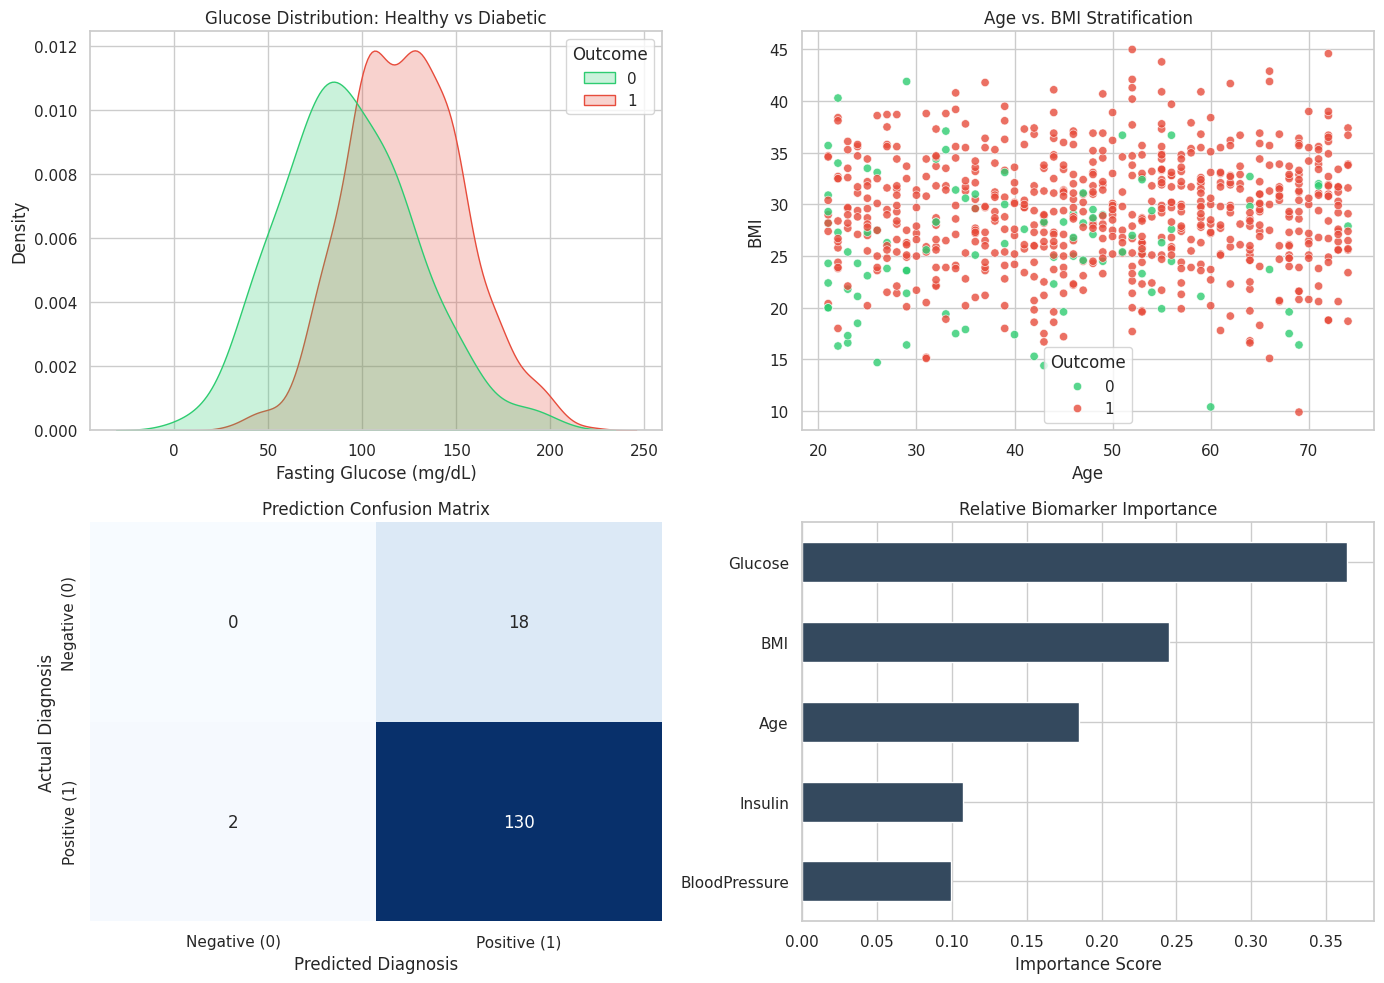

Dashboard visualization saved as clinical_project_dashboard.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Styling configuration
sns.set_theme(style="whitegrid")

# 1. Synthesize a Realistic Clinical Patient Dataset (Health Domain)
np.random.seed(42)
n_patients = 750

age = np.random.randint(21, 75, size=n_patients)
bmi = np.random.normal(28.5, 5.2, size=n_patients).round(1)
glucose = np.random.normal(120, 32, size=n_patients).round(1)
blood_pressure = np.random.normal(72, 12, size=n_patients).round(1)
insulin = np.random.exponential(scale=65, size=n_patients).round(1)

# Clinical risk logic for target outcome (0 = Non-Diabetic, 1 = Diabetic)
log_odds = -6.5 + (0.04 * age) + (0.08 * bmi) + (0.035 * glucose) + (0.01 * blood_pressure)
prob = 1 / (1 + np.exp(-log_odds))
outcome = (np.random.rand(n_patients) < prob).astype(int)

df = pd.DataFrame({
    "PatientID": range(5001, 5001 + n_patients),
        "Age": age,
            "BMI": bmi,
                "Glucose": glucose,
                    "BloodPressure": blood_pressure,
                        "Insulin": insulin,
                            "Outcome": outcome
                            })

# Save clinical dataset artifact
df.to_csv("patient_clinical_records.csv", index=False)
print("Clinical Dataset Shape:", df.shape)
print("\nOutcome Distribution:\n", df["Outcome"].value_counts(normalize=True))

# 2. Train-Test Split & Modeling
features = ["Age", "BMI", "Glucose", "BloodPressure", "Insulin"]
X = df[features]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# 3. Model Performance Evaluation
print("\n--- Clinical Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

# 4. End-to-End Visual Report
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Glucose Level Distribution by Outcome
sns.kdeplot(data=df, x="Glucose", hue="Outcome", fill=True, common_norm=False, palette=["#2ecc71", "#e74c3c"], ax=axes[0, 0])
axes[0, 0].set_title("Glucose Distribution: Healthy vs Diabetic")
axes[0, 0].set_xlabel("Fasting Glucose (mg/dL)")

# Plot 2: BMI vs Age Scatter with Outcome
sns.scatterplot(data=df, x="Age", y="BMI", hue="Outcome", palette=["#2ecc71", "#e74c3c"], alpha=0.8, ax=axes[0, 1])
axes[0, 1].set_title("Age vs. BMI Stratification")

# Plot 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1, 0],
            xticklabels=["Negative (0)", "Positive (1)"], yticklabels=["Negative (0)", "Positive (1)"])
axes[1, 0].set_title("Prediction Confusion Matrix")
axes[1, 0].set_xlabel("Predicted Diagnosis")
axes[1, 0].set_ylabel("Actual Diagnosis")

# Plot 4: Feature Importance
feature_importance = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
feature_importance.plot(kind="barh", color="#34495e", ax=axes[1, 1])
axes[1, 1].set_title("Relative Biomarker Importance")
axes[1, 1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("clinical_project_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()
print("Dashboard visualization saved as clinical_project_dashboard.png")